## 📎 Code this notebook uses
*(full map of every notebook → [`README.md`](README.md))*

- **Engine — `src/lunar/`:** `config`, `constants`, `grid`, `solver`, `plotting`
- **Data — `results/`:** `cpp_benchmark.json` (real Python / Numba / C++ timings)

> A scale-up demo: what does it take to simulate a **big region of the Moon**?
> We use **global values** (one Hayne conductivity, one albedo, one basal flux
> everywhere — no per-site retrieval) and compare the *process* of mapping it.

# Simulating a region of the Moon — comparing the process

The retrieval notebooks solve **one borehole** at a time. Here we ask the
scaling question: to make a **map**, we solve many surface pixels. This
notebook

1. times **one pixel** with the production (Numba) solver,
2. compares the cost of the **naive process** — solve every pixel — across the
   three solver backends (pure Python, Numba, C++), and extrapolates to the
   whole Moon,
3. shows the **smart process** — with global values the diurnal cycle depends
   only on latitude, so we solve each latitude once and assemble the map,
4. plots the resulting surface-temperature map.

Everything uses **global values**; nothing here is a per-site result.

In [1]:
import sys, time, json, pathlib
import numpy as np
import matplotlib.pyplot as plt

here = pathlib.Path.cwd()
CODE = next(p for p in [here, *here.parents] if (p / 'src' / 'lunar').exists())
sys.path.insert(0, str(CODE / 'src'))

from lunar.config import HAYNE, GRID, DT_STEP, SITES
from lunar.constants import Q_B_EQUATORIAL
from lunar.grid import make_geometric_grid
from lunar.solver import (solve_pixel, PixelInputs, standard_insolation,
                          periodic_time_grid)
from lunar.plotting import style                       # applies house rcParams
from lunar.plotting.style import fmt_axis

# ---- GLOBAL values (no per-site retrieval) -------------------------------
Ks, H, chi = HAYNE['K_S'], HAYNE['H'], HAYNE['CHI']
Kd_global  = 0.0034                                    # Hayne global K_d [W/m/K]
albedo     = float(np.mean([SITES[s]['albedo'] for s in ('A15', 'A17')]))
Q_b        = Q_B_EQUATORIAL
g = make_geometric_grid(**GRID)
t = periodic_time_grid(DT_STEP)
print(f'grid: {g.z_mid.size} cells to {g.z_mid[-1]:.1f} m, {t.size} steps/lunation')
print(f'GLOBAL values -> K_d={Kd_global*1e3:.1f} mW/m/K, '
      f'albedo={albedo:.3f}, Q_b={Q_b*1e3:.0f} mW/m^2')

grid: 69 cells to 4.8 m, 1417 steps/lunation
GLOBAL values -> K_d=3.4 mW/m/K, albedo=0.134, Q_b=18 mW/m^2


## 1 — One pixel, timed

`solve_pixel` marches the radiative surface energy balance to a converged
periodic cycle and returns the skin-temperature history. We warm up Numba
(first call compiles), then time a single equatorial pixel.

In [2]:
def one_solve(lat_deg):
    insol = standard_insolation(lat_deg, t)
    out = solve_pixel(PixelInputs(
        grid=g, t=t, bc_mode='radiative', insolation=insol, albedo=albedo,
        emissivity=0.95, Q_b=Q_b, n_lunations_spinup=80, spinup_tol_K=0.05,
        spinup_depth_m=0.15, hayne_params=(Ks, Kd_global, H, chi)))
    return out.T_surface

_ = one_solve(0.0)                                     # compile (not timed)
t0 = time.perf_counter(); T0 = one_solve(0.0); t_solve = time.perf_counter() - t0
print(f'one equatorial pixel, Numba solver: {t_solve:.3f} s')
print(f'  diurnal swing: night {T0.min():.0f} K  ->  noon {T0.max():.0f} K')

one equatorial pixel, Numba solver: 0.236 s
  diurnal swing: night 96 K  ->  noon 384 K


## 2 — The naive process: solve every pixel

A map is a grid of pixels; the naive method solves each one. Cost = (pixels) ×
(time per solve). We scale the measured Numba time by the **real** backend
ratios archived in `results/cpp_benchmark.json` (the head-to-head from
notebook 07) to get pure-Python and C++ costs, then extrapolate to a full
1°-resolution Moon.

In [3]:
# region of the map — a big patch, GLOBAL properties everywhere
lat_grid = np.arange(-75, 76, 3.0)                     # 51 rows
lon_grid = np.arange(-90, 91, 3.0)                     # 61 cols
n_region = lat_grid.size * lon_grid.size
n_full   = 181 * 361                                   # full 1-deg global grid

bench = json.loads((CODE / 'results' / 'cpp_benchmark.json').read_text())
r_py  = bench['py_ms_per_lunation']  / bench['py_njit_ms_per_lunation']  # ~111x
r_cpp = bench['cpp_ms_per_lunation'] / bench['py_njit_ms_per_lunation']  # ~0.68x

def fmt(s):
    return f'{s:5.1f} s' if s < 90 else (f'{s/60:5.1f} min' if s < 5400 else f'{s/3600:5.1f} h')

print(f'Region: {lat_grid.size} lat x {lon_grid.size} lon = {n_region} pixels '
      f'(global values)\n')
print(f'{"backend":<15}{"per pixel":>11}{"this region":>13}{"full 1-deg Moon":>17}')
print('-' * 56)
for name, per in [('pure Python', t_solve * r_py),
                  ('Numba (njit)', t_solve),
                  ('C++ port', t_solve * r_cpp)]:
    print(f'{name:<15}{per:>9.3f} s{fmt(per*n_region):>13}{fmt(per*n_full):>17}')

Region: 51 lat x 61 lon = 3111 pixels (global values)

backend          per pixel  this region  full 1-deg Moon
--------------------------------------------------------
pure Python       26.139 s       22.6 h          474.4 h
Numba (njit)       0.236 s     12.2 min            4.3 h
C++ port           0.161 s      8.3 min            2.9 h


## 3 — The smart process: exploit the symmetry

With **global values** the surface properties and forcing are identical at
every longitude, so a pixel's diurnal cycle depends only on its **latitude**
— longitude just sets the clock (local time). We therefore solve each unique
latitude **once** and read the map off by local solar time. Same map, ~60×
fewer solves.

In [4]:
uniq = np.unique(np.abs(lat_grid))                     # unique |lat|
t1 = time.perf_counter()
field = {la: one_solve(float(la)) for la in uniq}
t_smart = time.perf_counter() - t1
n_t = t.size
print(f'solved {uniq.size} unique latitudes in {t_smart:.1f} s '
      f'-> {n_region/uniq.size:.0f}x fewer solves than the naive {n_region}')

# assemble the instantaneous map at a chosen moment (noon on the 0-deg meridian)
sslon = 0.0
Tmap = np.empty((lat_grid.size, lon_grid.size))
for i, la in enumerate(lat_grid):
    curve = field[abs(la)]
    idx = (((lon_grid - sslon) % 360) / 360 * n_t).astype(int) % n_t
    Tmap[i] = curve[idx]
print(f'map temperature range: {Tmap.min():.0f} - {Tmap.max():.0f} K')

solved 26 unique latitudes in 6.0 s -> 120x fewer solves than the naive 3111
map temperature range: 80 - 384 K


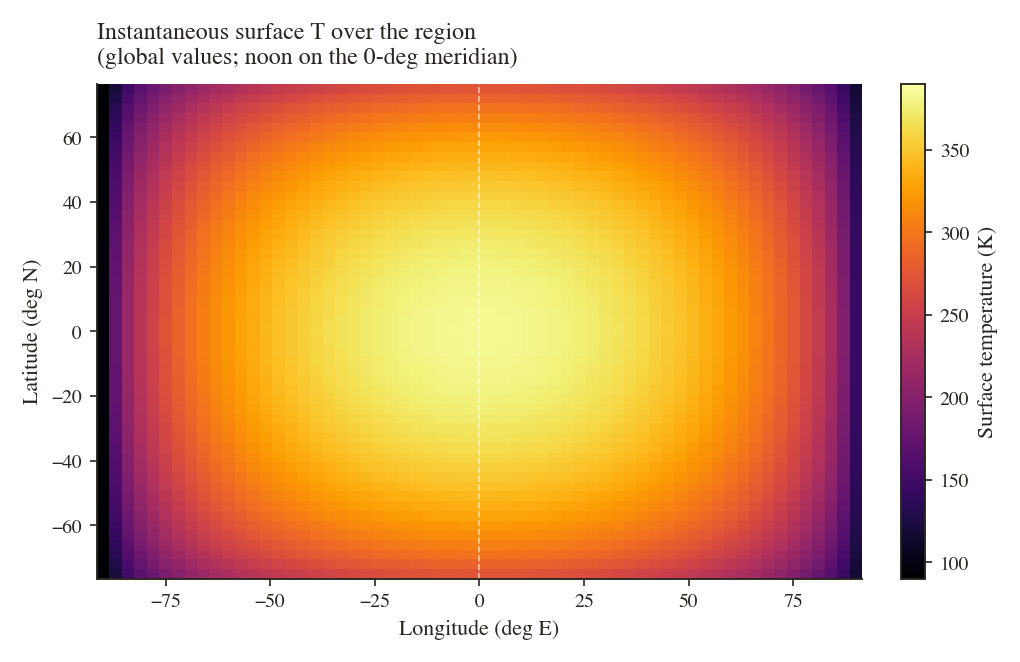

In [5]:
fig, ax = plt.subplots(figsize=(6.6, 4.2), constrained_layout=True)
pc = ax.pcolormesh(lon_grid, lat_grid, Tmap, cmap='inferno',
                   shading='auto', vmin=90, vmax=390)
cb = fig.colorbar(pc, ax=ax); cb.set_label('Surface temperature (K)')
ax.axvline(sslon, color='w', lw=0.8, ls='--', alpha=0.6)      # subsolar meridian
fmt_axis(ax, xlabel='Longitude (deg E)', ylabel='Latitude (deg N)',
         title='Instantaneous surface T over the region\n(global values; noon on the 0-deg meridian)')
plt.show()

## Takeaways

- **The solver is the bottleneck of any map.** A map is *N* independent solves,
  so the per-pixel cost decides feasibility. Pure Python would take **hours**
  for a full-Moon map; the Numba solver (production) and the C++ port both do
  it in **minutes** — and they agree to ~$10^{-12}$ K (notebook 07). That is
  why the science runs on Numba and C++ stays a cross-check.
- **Global values → 1-D problem.** With uniform properties the map is
  latitude-banded, so the real cost collapses from *N* pixels to a handful of
  unique latitudes. The moment you make properties **per-pixel** (local albedo,
  slope, or a retrieved per-site $K_d$), that symmetry breaks and you are back
  to the full *N*-solve cost in the table above — which is exactly when the
  fast solver earns its keep.